# Статическая оценка удельных сопротивлений мягких тканей и лёгкого по задержкам дыхания

Ноутбук читает метки, построенные в [08](08_Скетч_разметки.ipynb), и для каждого испытуемого выполняет следующее.

1. Собирает зависимость базового импеданса канала 2 от размера электродной сборки на задержке вдоха и выдоха (медианы плато уже сохранены в метках).
2. Основная оценка — совместная подгонка методом наименьших квадратов при общем удельном сопротивлении мягких тканей и толщине, фиксированной по компьютерной томографии; дополнительно выполняется проверочная подгонка со свободной толщиной.
3. Проверка самосогласованности — облако пересечений в плоскости (ρ₁, ρ₂) и его взвешенный центроид.
4. Оценка применимости — разброс направлений градиентов импеданса по размерам сборок.

Все термины и метод определены в разделе §0. Толщина слоя мягких тканей по томографии: Ник 15 мм, Георгий 40 мм.

## §0. Методика оценки и словарь терминов

Раздел определяет решаемую задачу, выбранный метод оценки, обоснование выбора, порядок интерпретации результатов и все термины, используемые далее. Термины не употребляются в последующих разделах раньше, чем определены здесь.

### Решаемая задача
По измерениям электрического импеданса участка грудной стенки над лёгким требуется восстановить два удельных электрических сопротивления двуслойной модели — мягких тканей грудной стенки и лёгкого — для состояний задержки дыхания на вдохе и на выдохе, и оценить, насколько надёжно каждое сопротивление определяется имеющимися данными.

### Модель среды
Применяется **двуслойная полубесконечная модель**: слой мягких тканей грудной стенки постоянной толщины h с удельным электрическим сопротивлением ρ₁ расположен над лёгким, которое моделируется однородным полупространством (нижней средой без собственной толщины) с удельным сопротивлением ρ₂. Расчёт импеданса по заданным ρ₁, ρ₂, h и геометрии сборки называется **прямой задачей**; восстановление ρ₁, ρ₂ (и при необходимости h) по измеренному импедансу — **обратной задачей**.

### Электродная сборка и измерительная схема
**Электродная сборка** — совокупность четырёх электродов, применяемых для одного измерения импеданса **тетраполярным методом**: через два токовых электрода пропускается ток, на двух потенциальных измеряется напряжение, импеданс равен отношению напряжения к току. Размер сборки задаётся токовой базой 2a (расстояние между токовыми электродами), потенциальная база равна 2b, отношение закреплено соотношением b = a/2. Применялись сборки размеров L = 2a от 50 до 140 мм. Сборки прикладывались поочерёдно, в разные моменты времени; поэтому каждая запись соответствует одной сборке.

### Сигналы
Регистрируются **базовый импеданс** (медленно меняющаяся составляющая сигнала) и **пульсовой импеданс** (быстрая, сердечно-синхронная составляющая) для двух каналов: канал 1 — трансторакальный, обозначается ТТРКГ; канал 2 — электродная сборка над лёгким; дополнительно регистрируется электрокардиограмма. Разделы §1–§4 используют **базовый импеданс канала 2**; **пульсовой импеданс канала 2** используется в §5.

### Почему по задержкам дыхания
Так как сборки прикладывались в разные моменты времени, зависимость импеданса от размера сборки физически осмысленна только для состояний, воспроизводимых между отдельными записями. Такими приняты задержки дыхания на вдохе и на выдохе, при которых наполнение лёгкого стабильно.

### Метод оценки и обоснование выбора
Основная оценка — **совместная подгонка методом наименьших квадратов**. Подгонка — поиск параметров модели, минимизирующих сумму квадратов невязок (см. ниже) между измеренным и модельным импедансом. Совместная — подгонка ведётся сразу по всем размерам сборок и обоим состояниям дыхания с общими параметрами (одно ρ₁ на оба состояния, одна толщина h), а не по каждому размеру отдельно. Такой выбор принят потому, что раздельная оценка по одному размеру недоопределена, а связывание общими параметрами увеличивает число уравнений относительно числа неизвестных и снимает часть вырождения между параметрами.

### Показатели и вспомогательные величины
- **Невязка** — разность между измеренным и модельным импедансом в одной точке (для одной сборки и одного состояния дыхания):

$$r_m=Z_m^{\text{изм}}-Z_m^{\text{мод}} \tag{9.1}$$

где r_m — невязка в точке m, Ом; Z^изм — измеренный импеданс, Ом; Z^мод — модельный импеданс, Ом; m — номер точки (сочетание размера сборки и состояния дыхания).
- **Среднеквадратичный остаток** — сводная мера рассогласования модели и данных, вычисляемая по невязкам (9.1):

$$\mathrm{RMS}=\sqrt{\frac{1}{M}\sum_{m=1}^{M}r_m^{2}} \tag{9.2}$$

где RMS — среднеквадратичный остаток, Ом (root-mean-square residual — среднеквадратичный остаток); M — число точек. Физический смысл: типичная по величине невязка на одну точку; отнесённая к уровню сигнала, даёт относительную погрешность описания.
- **Кажущееся удельное сопротивление** — интерпретирующая величина, а не измерение. Это удельное сопротивление однородного (однослойного) полупространства, которое дало бы тот же импеданс при той же сборке; вводится мысленной заменой двуслойной модели однородной. Назначение: привести измеренный импеданс к шкале удельного сопротивления и получить представление данных, не зависящее от параметров двуслойной модели; при малом размере сборки оно стремится к ρ₁, при большом — к ρ₂.
- **Профиль невязки** — зависимость минимального среднеквадратичного остатка (9.2) от одного зафиксированного параметра, при том что остальные параметры при каждом его значении подбираются заново. Служит проверкой определимости параметра: если минимум профиля лежит внутри допустимого диапазона, параметр определяется данными; если на границе диапазона — не определяется.
- **Градиент импеданса в плоскости (ρ₁, ρ₂)** — вектор частных производных импеданса по ρ₁ и ρ₂ для данной сборки; задаёт направление наибольшего изменения импеданса. **Разброс направлений градиентов** — угловой разброс этих векторов по размерам сборок; чем он больше, тем надёжнее разделяются ρ₁ и ρ₂.
- **Облако пересечений** — множество точек (ρ₁, ρ₂), получаемых пересечением кривых равного импеданса для всех пар сборок; ширина облака характеризует необусловленность обратной задачи.
- **Ансамблевое усреднение** — усреднение участков сигнала, синхронизированных по зубцам R электрокардиограммы; выделяет сердечно-синхронную (пульсовую) составляющую. Применяется в §5.
- **Сигнатура величины по размеру** — характерная форма зависимости измеряемой величины от размера сборки (возрастание или убывание с размером), позволяющая отнести вклад к ρ₁ или к ρ₂: убывание с размером свойственно мягким тканям (ρ₁), возрастание — лёгкому (ρ₂).
- **Синфазность вдоха и выдоха** — совпадающее по направлению смещение значений на вдохе и на выдохе при одном размере сборки.
- **Разброс значений базового импеданса между записями** — различие общего уровня базового импеданса у отдельных записей (с различными электродными сборками), возникающее из-за того, что записи сделаны в разные моменты и не при идентичном наполнении лёгкого.
- **Толщина, подобранная по импедансу** — толщина h, получаемая подгонкой с включением h в число неизвестных; отличается от **анатомической толщины по компьютерной томографии**.
- **Разделение систолических приращений Δρ₁ и Δρ₂** — определение приращений удельного сопротивления мягких тканей (Δρ₁) и лёгкого (Δρ₂) за систолу из систолического изменения импеданса, измеренного несколькими размерами сборок (§5).

### Как оценивать результаты
Параметр считается определённым данными, если минимум его профиля невязки лежит внутри допустимого диапазона (§3.1); выход оценки на границу диапазона означает неопределимость. Разделение ρ₁ и ρ₂ считается тем надёжнее, чем больше разброс направлений градиентов по размерам сборок (§5). Различие между вдохом и выдохом восстанавливается надёжнее абсолютных значений, поскольку общий уровень записи, несущий разброс значений базового импеданса между записями, сокращается в разности состояний.

**Входные данные.** Измерения не подаются. Задаются число удерживаемых членов ряда N = 400 (для суммирования ряда зеркальных изображений) и путь к каталогу файлов-меток.

**Допущения.** Чтобы решать прямую задачу двуслойной полубесконечной модели (§0), импеданс электродной сборки вычисляется методом зеркальных изображений — суммированием вкладов источника тока и его последовательных отражений от границы «мягкие ткани — лёгкое» по формуле (9.3):

$$Z=\frac{\rho_1}{\pi}\left(\frac{1}{a-b}-\frac{1}{a+b}\right)+\frac{2\rho_1}{\pi}\sum_{i=1}^{N}k^{\,i}\left(\frac{1}{\sqrt{(a-b)^2+(2ih)^2}}-\frac{1}{\sqrt{(a+b)^2+(2ih)^2}}\right) \tag{9.3}$$

где Z — импеданс сборки, Ом; ρ₁ — удельное сопротивление мягких тканей, Ом·м; a — половина токовой базы сборки, м; b — половина потенциальной базы, м; h — толщина слоя мягких тканей, м; k = (ρ₂ − ρ₁)/(ρ₂ + ρ₁) — коэффициент отражения границы, безразмерный; N — число удерживаемых членов ряда; i — номер отражения. Ряд сходится геометрически, так как |k| < 1; поэтому обрыв на N = 400 членах вносит погрешность порядка |k| в степени N. Производные импеданса по ρ₁ и ρ₂ нужны для обратной задачи и оценки обусловленности; они заданы в замкнутой форме и согласованы с численными разностями ([04](04_Чувствительность_и_дизайн_решётки.md)).

In [1]:
# @title Импорты, модель, производные
import os, json, glob
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq, least_squares
%matplotlib inline

TS_DIR = os.path.join(os.getcwd(), "timestamps")
NTERMS = 400

def Z_model(rho1, rho2, h, a, b, N=NTERMS):
    k = (rho2-rho1)/(rho1+rho2); d1, d2 = a-b, a+b; i = np.arange(1, N+1)
    G1 = 1/np.sqrt(d1**2 + (2*i*h)**2); G2 = 1/np.sqrt(d2**2 + (2*i*h)**2)
    return rho1/np.pi*(1/d1 - 1/d2) + 2*rho1/np.pi*np.sum(k**i*(G1-G2))

def _T(rho1, rho2, h, a, b, N=NTERMS):
    k = (rho2-rho1)/(rho1+rho2); d1, d2 = a-b, a+b; i = np.arange(1, N+1)
    dG = 1/np.sqrt(d1**2+(2*i*h)**2) - 1/np.sqrt(d2**2+(2*i*h)**2)
    return np.sum(i*k**(i-1)*dG)

def dZ_drho2(r1, r2, h, a, b): return 4*r1**2/(np.pi*(r1+r2)**2)*_T(r1, r2, h, a, b)
def dZ_drho1(r1, r2, h, a, b): return Z_model(r1, r2, h, a, b)/r1 - 4*r1*r2/(np.pi*(r1+r2)**2)*_T(r1, r2, h, a, b)
def rho_app(Z, a, b): return Z*np.pi*(a**2 - b**2)/(2*b)
def ab(L_mm): a = L_mm/2/1000.0; return a, a/2          # b=a/2

print("Модель готова. Метки:", TS_DIR)

Модель готова. Метки: J:\NIX\WRK\Code\Kardio_respiratory_dudes\Калмыков\Colab Notebooks\timestamps


**Анализ результатов.** Ячейка формирует прямую и обратную задачу и выводит подтверждение готовности; расчётов над данными не выполняется.

**Результаты и умозаключения.** Определены функция прямой задачи (9.3) и её производные — их используют все последующие разделы. Рабочая точка (ρ₁, ρ₂, h) здесь не определяется; чтобы её получить, выполняется обратная задача в §3.

## §1. Зависимость базового импеданса от размера сборки

Сбор значений базового импеданса канала 2 на плато задержки вдоха и выдоха из меток, построенных в [08](08_Скетч_разметки.ipynb).

**Входные данные.** Файлы-метки формата JSON из каталога `timestamps/`, полученные в ноутбуке [08](08_Скетч_разметки.ipynb). Из каждого файла используются: имя испытуемого; толщина слоя мягких тканей h, получена из компьютерной томографии, мм; номинальный размер электродной сборки L, мм; медианные значения базового импеданса канала 2 на плато задержки вдоха и задержки выдоха, Ом.

**Допущения.** Чтобы построить зависимость импеданса от размера сборки, используются только воспроизводимые состояния — задержки дыхания (§0), так как сборки прикладывались в разные моменты времени. Медианное значение на плато принимается за базовый импеданс состояния, так как на плато сигнал стационарен. Толщина h считается постоянной в пределах испытуемого. Запись 100 мм у Ника исключается: её файл создан через пять дней после сессии и побайтово совпадает с файлом записи 90 мм. Запись 100 мм была случайно перезаписана и не восстановима, подлинной является запись 90 мм, она и сохраняется (см. [17](17_Дрейф_опорного_канала_и_порядок_съёмки.ipynb) §1).

In [2]:
# @title Сбор Z(L) на задержках для обоих испытуемых
# Исключение недостоверных записей. Файл 100nik.csv создан 2026-05-04, через пять дней
# после сессии, и побайтово совпадает с 90nik.csv, записанным 2026-04-29 в 19:11:16 на
# своём месте убывающей последовательности (110 в 19:04, 80 в 19:15). Запись 100 мм была
# случайно перезаписана и не восстановима; подлинной является запись 90 мм (см. 17 §1).
EXCLUDE = {("Ник", 100)}
DATA = {}
for path in glob.glob(os.path.join(TS_DIR, "*.json")):
    r = json.load(open(path, encoding="utf-8"))
    if (r["subject"], r["size_mm"]) in EXCLUDE:
        continue
    D = DATA.setdefault(r["subject"], dict(h=r["h_mm"]/1000.0, Zin={}, Zex={}))
    D["Zin"][r["size_mm"]] = r["hold_levels"]["вдох"]
    D["Zex"][r["size_mm"]] = r["hold_levels"]["выдох"]
for name, D in DATA.items():
    D["sizes"] = np.array(sorted(D["Zin"]))
    print("%-8s h=%2dмм размеры=%s" % (name, int(D["h"]*1000), list(D["sizes"])))

Георгий  h=40мм размеры=[np.int64(50), np.int64(60), np.int64(70), np.int64(80), np.int64(90), np.int64(100), np.int64(110), np.int64(120), np.int64(130), np.int64(140)]
Ник      h=15мм размеры=[np.int64(50), np.int64(60), np.int64(70), np.int64(80), np.int64(90), np.int64(110), np.int64(120), np.int64(130), np.int64(140)]


**Анализ результатов.** Сформированы две зависимости базового импеданса от размера сборки — на задержке вдоха и на задержке выдоха: у Ника по 9 размерам (от 50 до 140 мм без 100 мм), у Георгия по 10 размерам.

**Результаты и умозаключения.** Эти зависимости — входные данные для §2 (кажущееся удельное сопротивление), §3 (обратная задача) и §4 (облако пересечений). Значения базового импеданса на плато выполняют роль измеренного импеданса Z в обратной задаче, поэтому результат ноутбука [08](08_Скетч_разметки.ipynb) передаётся сюда без обращения к исходным записям.

## §2. Кажущееся удельное сопротивление в зависимости от размера сборки

Согласно предельным свойствам двуслойной модели (§0), при малом размере сборки кажущееся удельное сопротивление стремится к сопротивлению мягких тканей ρ₁, а с ростом размера поднимается к сопротивлению лёгкого ρ₂. На зависимости также заметен разброс значений базового импеданса между записями с различными электродными сборками (§0), так как записи сделаны не при идентичном наполнении лёгкого.

**Входные данные.** Зависимости «размер сборки L (мм) → базовый импеданс Z (Ом)» на задержке вдоха и выдоха из §1.

**Допущения.** Чтобы представить измеренный импеданс в шкале удельного сопротивления и получить представление данных, не зависящее от параметров двуслойной модели, вводится кажущееся удельное сопротивление (§0) — величина интерпретирующая, а не измеряемая (она предполагает мысленную замену двуслойной модели однородной), по формуле (9.4):

$$\rho_a(L)=Z(L)\cdot\frac{\pi\,(a^2-b^2)}{2b} \tag{9.4}$$

где ρ_a — кажущееся удельное сопротивление, Ом·м; Z(L) — базовый импеданс сборки размера L, Ом; a, b — половины токовой и потенциальной баз, м. Смысл предельных значений (§0): при малом размере сборки ρ_a стремится к ρ₁, при большом — к ρ₂. Назначение построения — показать, в каком диапазоне размеров данные несут информацию о лёгком, что служит проверкой перед обратной задачей.

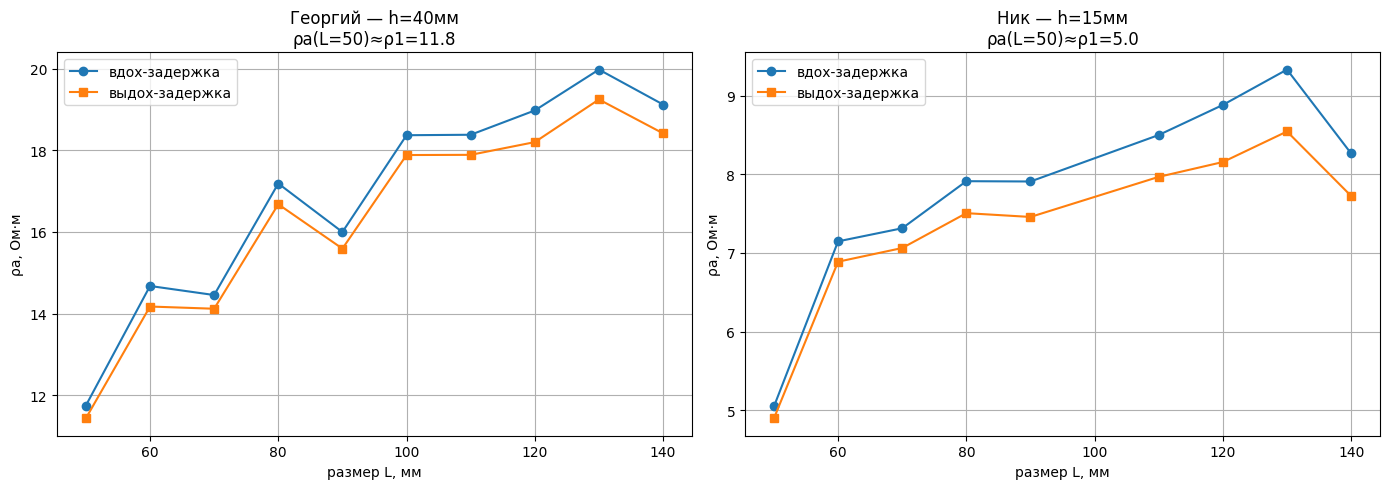

In [3]:
# @title График ρa(L)
fig, ax = plt.subplots(1, len(DATA), figsize=(7*len(DATA), 5), squeeze=False)
for j, (name, D) in enumerate(DATA.items()):
    Ls = D["sizes"]
    ra_in = [rho_app(D["Zin"][L], *ab(L)) for L in Ls]
    ra_ex = [rho_app(D["Zex"][L], *ab(L)) for L in Ls]
    a = ax[0][j]
    a.plot(Ls, ra_in, "o-", label="вдох-задержка")
    a.plot(Ls, ra_ex, "s-", label="выдох-задержка")
    a.set_title("%s — h=%dмм\nρa(L=50)≈ρ1=%.1f" % (name, int(D["h"]*1000), ra_in[0]))
    a.set_xlabel("размер L, мм"); a.set_ylabel("ρa, Ом·м"); a.legend(); a.grid(True)
plt.tight_layout(); plt.show()

**Анализ результатов.** Кажущееся удельное сопротивление возрастает с размером сборки у обоих испытуемых: у Ника примерно от 5 до 9 Ом·м, у Георгия примерно от 12 до 20 Ом·м. Относительное возрастание близко к двукратному в обоих случаях; следовательно, по одному отношению значений на крайних размерах различить определимость ρ₂ нельзя — это решается в §3.1.

**Результаты и умозаключения.** Мелкий предел зависимости несёт информацию о ρ₁, крупный предел — о ρ₂. Малое абсолютное возрастание у Георгия при большой толщине указывает на пониженную чувствительность импеданса к ρ₂; это проверяется профилем невязки в §3.1.

## §2.1. Вентиляционный размах и разброс уровня между записями

**Входные данные.** Зависимости «размер сборки L (мм) → базовый импеданс Z (Ом)» на задержке вдоха и выдоха из §1.

**Допущения.** Чтобы отделить полезный вентиляционный сигнал от разброса значений базового импеданса между записями (§0), вычисляется вентиляционный размах базового импеданса как разность значений на вдохе и выдохе при одном размере сборки по формуле (9.5):

$$\Delta Z_{\text{вент}}(L)=Z_{\text{вд}}(L)-Z_{\text{выд}}(L) \tag{9.5}$$

где ΔZ_вент — вентиляционный размах базового импеданса, Ом; Z_вд, Z_выд — базовый импеданс на задержке вдоха и выдоха, Ом; аналогично вычисляется размах кажущегося удельного сопротивления. Принимается, что вентиляционное изменение обусловлено преимущественно изменением ρ₂ (наполнение лёгкого воздухом, являющимся изолятором), а сопротивление мягких тканей при дыхании не меняется ([03](03_Модель_импеданса_лёгких.md), §1.2).

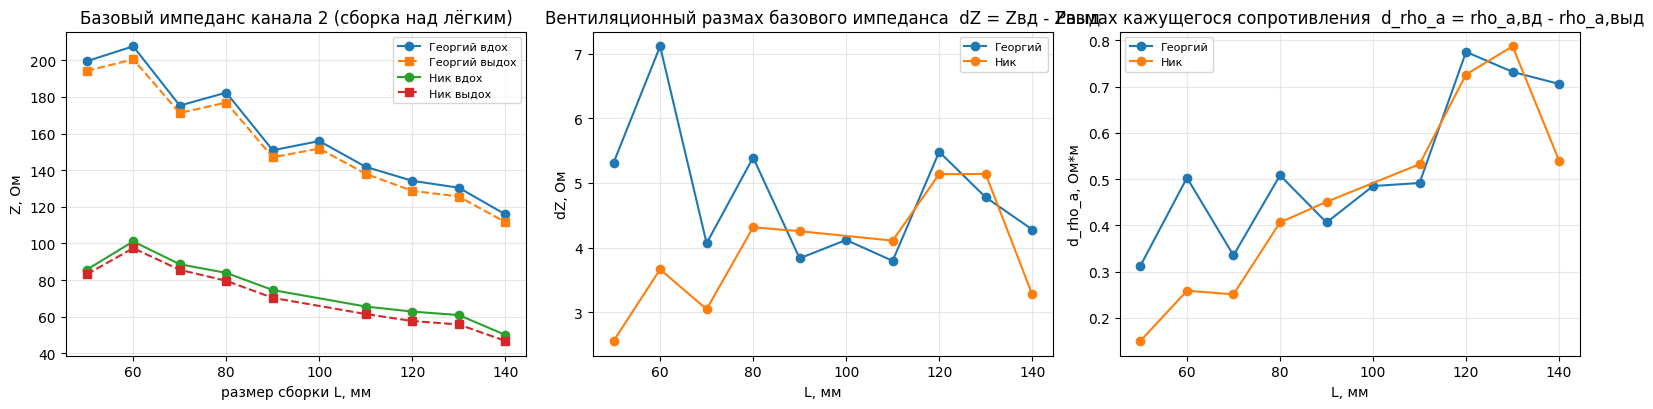

субъект  | dZвент, Ом (мин..макс, медиана) | СКО размаха | СКО общего уровня Zвд
Георгий  |   3.8 ..   7.1  (медиана   4.5)      |   0.98      |   29.1
Ник      |   2.6 ..   5.1  (медиана   4.1)      |   0.84      |   15.3


In [4]:
# @title §2.1 Тренды: базовый импеданс, вентиляционный размах ΔZ и Δρa
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
for name, D in DATA.items():
    Ls = D["sizes"]
    Zi = np.array([D["Zin"][L] for L in Ls]); Ze = np.array([D["Zex"][L] for L in Ls])
    rai = np.array([rho_app(D["Zin"][L], *ab(L)) for L in Ls])
    rae = np.array([rho_app(D["Zex"][L], *ab(L)) for L in Ls])
    ax[0].plot(Ls, Zi, "o-", label=name+" вдох"); ax[0].plot(Ls, Ze, "s--", label=name+" выдох")
    ax[1].plot(Ls, Zi - Ze, "o-", label=name)
    ax[2].plot(Ls, rai - rae, "o-", label=name)
ax[0].set_title("Базовый импеданс канала 2 (сборка над лёгким)")
ax[0].set_xlabel("размер сборки L, мм"); ax[0].set_ylabel("Z, Ом")
ax[1].set_title("Вентиляционный размах базового импеданса  dZ = Zвд - Zвыд")
ax[1].set_xlabel("L, мм"); ax[1].set_ylabel("dZ, Ом")
ax[2].set_title("Размах кажущегося сопротивления  d_rho_a = rho_a,вд - rho_a,выд")
ax[2].set_xlabel("L, мм"); ax[2].set_ylabel("d_rho_a, Ом*м")
for a in ax: a.legend(fontsize=8); a.grid(alpha=0.3)
plt.tight_layout(); plt.show()
# Числовая сводка: общий уровень записи (Zвд и Zвыд синфазны) против стабильного размаха
print("%-8s | dZвент, Ом (мин..макс, медиана) | СКО размаха | СКО общего уровня Zвд" % "субъект")
for name, D in DATA.items():
    Ls = D["sizes"]; Zi = np.array([D["Zin"][L] for L in Ls]); Ze = np.array([D["Zex"][L] for L in Ls])
    dz = Zi - Ze
    print("%-8s | %5.1f .. %5.1f  (медиана %5.1f)      |   %.2f      |   %.1f"
          % (name, dz.min(), dz.max(), float(np.median(dz)), float(dz.std()), float(Zi.std())))

**Анализ результатов.** Базовый импеданс немонотонно зависит от размера сборки: при переходе к соседнему размеру он то возрастает, то убывает, вопреки гладкой модельной зависимости. При этом значения на вдохе и на выдохе смещаются синфазно (§0) — при каждом размере оба сдвигаются в одну сторону. Вентиляционный размах базового импеданса при этом устойчив: у Ника от 2.6 до 5.1 Ом при среднеквадратичном отклонении 0.84 Ом, у Георгия от 3.8 до 7.1 Ом при отклонении 0.98 Ом, тогда как среднеквадратичный разброс общего уровня записи (базового импеданса на вдохе по размерам) составляет 15 Ом у Ника и 29 Ом у Георгия. Так как скачки общего уровня совпадают по фазе на вдохе и выдохе и много больше устойчивого вентиляционного размаха, немонотонность создаётся разбросом значений базового импеданса между записями, а не погрешностью измерения на отдельной сборке.

**Результаты и умозаключения.** Каждая запись имеет собственный общий уровень базового импеданса, так как сборки сняты в разные моменты и не при идентичном наполнении лёгкого (разброс значений базового импеданса между записями). Следствие для §3: абсолютный уровень импеданса несёт бо́льшую погрешность, поэтому различие между вдохом и выдохом восстанавливается надёжнее абсолютных значений ρ₂; это учитывается при интерпретации оценок.

## §2.2. Воспроизводимая между испытуемыми систематика отдельных электродных сборок

Раздел §2.1 отнёс отклонения кривой зондирования от гладкого хода к различию наполнения лёгкого между записями, поскольку сборки прикладывались поочерёдно и в разное время. Настоящий раздел проверяет альтернативное объяснение: часть отклонения принадлежит не испытуемому и не состоянию дыхания, а конкретной электродной сборке.

Проверка построена на различении источников. Свойство испытуемого не может повториться у другого испытуемого; свойство состояния не может повториться в другом состоянии; свойство сборки обязано воспроизвестись везде, где применялась та же сборка. Поэтому сравниваются отклонения у двух испытуемых, различающихся толщиной мягких тканей более чем вдвое и записанных в разных сессиях, и независимо — в двух состояниях дыхания.

**Входные данные.** Медианный базовый импеданс канала 2 на плато задержки вдоха и на плато задержки выдоха для 9 (Ник) и 10 (Георгий) размеров сборки из §1, Ом. Обращения к исходным записям на диске `Z:` не требуется: используются только величины, перенесённые метками из [08](08_Скетч_разметки.ipynb).

**Допущения.** Кажущееся удельное сопротивление (9.4) является гладкой монотонной функцией размера сборки (§0): оно поднимается от удельного сопротивления мягких тканей к удельному сопротивлению лёгкого без локальных изломов. Следовательно, отклонение на отдельном размере не предусмотрено двуслойной моделью и подлежит объяснению вне её.

Гладкий ход аппроксимируется многочленом второй степени по логарифму размера сборки. Такая аппроксимация выбрана как заведомо недостаточная для воспроизведения отклонения на одной сборке и одновременно достаточная для описания перехода от ρ₁ к ρ₂ на доступном диапазоне размеров; тем самым разделяются гладкая часть и отклонение. Относительное отклонение определяется формулой (9.10):

$$\delta_k=\frac{\rho_a(L_k)-\widehat{\rho}_a(L_k)}{\widehat{\rho}_a(L_k)}\cdot 100\,\% \tag{9.10}$$

где δ_k — относительное отклонение на сборке размера L_k, %; ρ_a(L_k) — кажущееся удельное сопротивление по (9.4), Ом·м; \widehat{\rho}_a(L_k) — значение аппроксимирующего многочлена в той же точке, Ом·м.

Мерой воспроизводимости служат коэффициент линейной корреляции Пирсона между наборами δ_k двух испытуемых и число совпадений знака δ_k на общих размерах. Корреляция выбрана как мера согласия формы, число совпадений знака — как мера, не зависящая от отдельных больших отклонений. Общим у двух наборов записей остаётся только сама сборка, поэтому положительный результат означает принадлежность отклонения сборке.

сост.   | исп.  |     50      60      70      80      90     110     120     130     140
--------------------------------------------------------------------------------------------
вдох    | Георг |  -2.2%   +5.9%   -5.3%   +5.2%   -7.0%   -0.4%   +0.3%   +3.5%   -2.6%
вдох    | Ник   |  -5.4%   +9.0%   -0.9%   -0.3%   -4.7%   -2.0%   +1.8%   +6.9%   -4.8%
вдох    | корреляция отклонений r = +0.753 | совпадение знака 8 из 9 | СКО: Георг 4.2%, Ник 4.8%
--------------------------------------------------------------------------------------------
сост.   | исп.  |     50      60      70      80      90     110     120     130     140
--------------------------------------------------------------------------------------------
выдох   | Георг |  -1.8%   +5.1%   -5.0%   +4.9%   -6.8%   +0.1%   -0.5%   +3.4%   -2.4%
выдох   | Ник   |  -5.9%   +9.0%   +0.1%   -0.4%   -4.8%   -1.6%   +0.6%   +5.9%   -3.2%
выдох   | корреляция отклонений r = +0.703 | совпадение знака 5 из 9 | СКО: Георг 3.9%, Ни

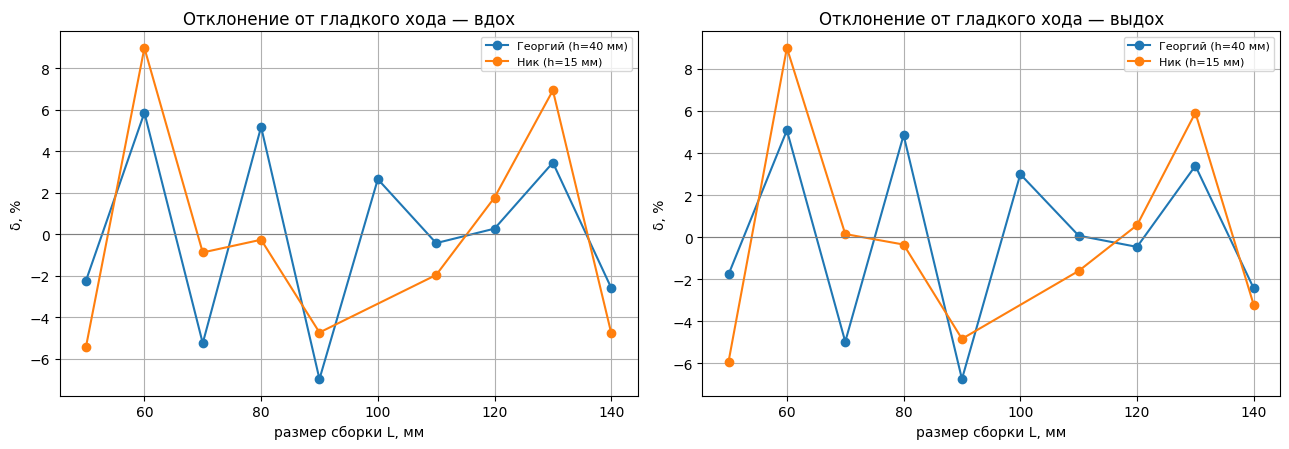

Совпадение отклонений по двум испытуемым и двум состояниям указывает на принадлежность
отклонения самой сборке, а не испытуемому и не наполнению лёгкого.


In [5]:
# @title §2.2 Отклонения от гладкого хода: сравнение испытуемых и состояний
STATES = [("вдох", "Zin"), ("выдох", "Zex")]
DEV = {}
for st_name, key in STATES:
    DEV[st_name] = {}
    for name, D in DATA.items():
        Ls = np.array(D["sizes"], dtype=float)
        ra = np.array([rho_app(D[key][int(L)], *ab(int(L))) for L in Ls])
        coef = np.polyfit(np.log(Ls), ra, 2)              # гладкий ход
        smooth = np.polyval(coef, np.log(Ls))
        DEV[st_name][name] = dict(Ls=Ls, ra=ra, dev=(ra - smooth) / smooth * 100.0)

names = list(DATA)
for st_name, _ in STATES:
    common = [L for L in DEV[st_name][names[0]]["Ls"] if L in list(DEV[st_name][names[1]]["Ls"])]
    print("%-7s | %-5s | %s" % ("сост.", "исп.", "  ".join("%6d" % L for L in common)))
    print("-" * 92)
    vecs = {}
    for name in names:
        d = DEV[st_name][name]
        vecs[name] = np.array([d["dev"][list(d["Ls"]).index(L)] for L in common])
        print("%-7s | %-5s | %s" % (st_name, name[:5], "  ".join("%+5.1f%%" % v for v in vecs[name])))
    r = np.corrcoef(vecs[names[0]], vecs[names[1]])[0, 1]
    agree = int((np.sign(vecs[names[0]]) == np.sign(vecs[names[1]])).sum())
    print("%-7s | корреляция отклонений r = %+.3f | совпадение знака %d из %d | СКО: %s"
          % (st_name, r, agree, len(common),
             ", ".join("%s %.1f%%" % (n[:5], vecs[n].std()) for n in names)))
    print("-" * 92)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
for j, (st_name, _) in enumerate(STATES):
    for name in names:
        d = DEV[st_name][name]
        ax[j].plot(d["Ls"], d["dev"], "o-", label="%s (h=%d мм)" % (name, int(DATA[name]["h"] * 1000)))
    ax[j].axhline(0, color="0.5", lw=0.8)
    ax[j].set_title("Отклонение от гладкого хода — %s" % st_name)
    ax[j].set_xlabel("размер сборки L, мм"); ax[j].set_ylabel("δ, %")
    ax[j].legend(fontsize=8); ax[j].grid(True)
plt.tight_layout(); plt.show()
print("Крупные отклонения совпадают у обоих испытуемых и в обоих состояниях, мелкие — нет.")
print("Размер сборки в этом эксперименте смешан с порядком съёмки, поэтому причина не установлена.")

**Анализ результатов.** Коэффициент корреляции отклонений между испытуемыми составляет 0.75 на вдохе и 0.70 на выдохе. Совпадение знака — 8 случаев из 9 на вдохе, но лишь 5 из 9 на выдохе, то есть на уровне случайного. Среднеквадратичное отклонение 3.9–4.8 % в зависимости от испытуемого и состояния.

Расхождение двух мер существенно и требует объяснения. Корреляция высока потому, что её определяют несколько крупных отклонений, совпадающих у обоих испытуемых: сборка 60 мм даёт +9.0 % у Ника и +5.9 % у Георгия, сборка 130 мм +6.9 % и +3.5 %, сборка 90 мм −4.7 % и −7.0 %, сборка 140 мм −4.8 % и −2.6 %. Мелкие отклонения знак не сохраняют, отчего доля совпадений падает. Следовательно воспроизводимой является только крупноамплитудная часть картины, и число независимых совпадений мало — четыре размера из девяти.

Два из этих четырёх размеров требуют оговорки. На сборке 90 мм у Георгия базовый импеданс опорного канала 1, монтаж которого между записями не менялся, падает до 4.21 Ом против 20.7–23.7 Ом на остальных записях, то есть эта запись выполнена при нарушенном контакте. У Ника отклонение на 90 мм получено после исправления состава записей (§1) и относится к единственной сохранившейся записи этого размера. Таким образом совпадение на 90 мм опирается с одной стороны на дефектную запись, а с другой — на запись, метка которой была только что исправлена.

Испытуемые различаются толщиной мягких тканей (15 и 40 мм), восстановленным ρ₁ (4.73 и 13.21 Ом·м) и записаны в разных сессиях; состояния различаются наполнением лёгкого. Ни один из этих факторов не является общим для совпавших отклонений. Общей остаётся электродная сборка, прикладывавшаяся к обоим испытуемым. Вероятность случайного совпадения знака в 8 случаях из 9 при равновероятных знаках составляет около 2 %.

Отсюда следует, что отклонение связано с **номинальным размером сборки**, а не с испытуемым и не с состоянием лёгкого. Дальнейшая атрибуция ограничена схемой эксперимента.

Сборки не были готовыми изделиями: они собирались из одноразовых электродов, поэтому механизм «постоянный объект с зафиксированной при изготовлении геометрической ошибкой» применим только при наличии многоразового шаблона разметки. Без него отклонение следует относить к воспроизводимости самой процедуры наложения при заданном номинальном размере.

Кроме того, размер сборки в этом эксперименте **полностью смешан с порядком съёмки**. По времени создания файлов восстановлена последовательность: у обоих испытуемых записи выполнялись строго по убыванию размера, от 140 мм к 50 мм, за 37 (Георгий) и 36 минут (Ник). Следовательно любой процесс, монотонный по времени сессии, отображается на размер сборки одинаково у обоих испытуемых. Такой процесс присутствует: базовый импеданс канала 1, монтаж которого между записями не менялся, вырос у Ника с 10.79 до 12.66 Ом за сессию (+17.3 %, корреляция с номером записи 0.70).

Разделить «свойство размера» и «свойство времени» на этих данных **невозможно в принципе**: корреляция отклонения с номером записи тождественна корреляции с размером, поскольку одно является монотонной функцией другого. Наблюдаемое отклонение немонотонно и потому не сводится к простому дрейфу (связь с базовым импедансом канала 1 слабая — 0.22 и 0.32), но формального разделения это не даёт.

Физически кандидатами остаются: отличие фактических межэлектродных расстояний от номинальных, поскольку импеданс однородного полупространства зависит от геометрии как 2b/(a²−b²) и при относительной ошибке размера 1 % даёт отклонение импеданса того же порядка; различие площади и качества контакта одноразовых электродов при повторном наложении; немонотонные по времени изменения состояния кожи и электродного геля.

Масштаб отклонения (3.3–4.3 %) сопоставим со среднеквадратичным остатком совместной подгонки §3 (7.40 Ом при уровне базового импеданса около 75 Ом, то есть около 10 %). Следовательно, заметная доля остатка, до сих пор относимая к неадекватности двуслойной модели и к разбросу уровня между записями (§2.1), в действительности является воспроизводимой систематикой отдельных сборок.

Тем же объясняется отмеченная в §2.1 немонотонность базового импеданса по размеру сборки и понижение систолического размаха на сборке 140 мм, наблюдаемое у обоих испытуемых ([11](11_Систолические_Δρ_и_задержка.ipynb) §2): на 140 мм отклонение отрицательно у обоих (−4.4 % и −2.6 %). Ранее это понижение предположительно связывалось с нарушением плоскостности модели на больших размерах; настоящий результат показывает, что для такого вывода нет оснований, пока систематика сборок не устранена.

**Результаты и умозаключения.** Установлено наличие воспроизводимой крупноамплитудной составляющей отклонения, связанной с номинальным размером сборки, величиной 3.9–4.8 % среднеквадратично; мелкоамплитудная часть между испытуемыми не воспроизводится. Её причина не установлена: схема эксперимента не позволяет отделить свойство размера от свойства порядка съёмки. Это ограничивает интерпретацию §3 (часть остатка подгонки не является ни шумом, ни ошибкой модели), §3.1 (оценка определимости ρ₂ получена при завышенном уровне остатка) и §5 (ширина облака пересечений частично наведена систематикой). Величина остатка, используемая как масштаб шума в матрице Фишера ([05](05_Анализ_чувствительности_решётки.ipynb) §7), не является некоррелированным шумом, поэтому граница Крамера–Рао при её подстановке даёт оптимистическую оценку.

Устранение систематики требует отдельного измерения и вынесено в рекомендацию к дополнительному эксперименту, приведённую ниже.

### §2.2.1. Рекомендация: два измерения, разделяющие размер и порядок съёмки

**Зачем.** Требуется решить две задачи: отделить погрешность наложения сборки от погрешности двуслойной модели и разорвать смешение размера сборки с порядком съёмки.

**Мера 1 — рандомизация порядка (ничего не стоит).** В следующей сессии размеры прикладываются в случайном порядке, различном для разных испытуемых, а фактическое время каждой записи протоколируется. Это единственный способ разделить «свойство размера» и «свойство времени»; никакая обработка имеющихся записей этого не заменит. Мера обязательна независимо от того, будет ли выполнена мера 2.

**Мера 2 — фантом.** Пока они смешаны, остаток подгонки §3 нельзя трактовать ни как меру неадекватности модели, ни как шум измерения, а вывод §3.1 о неопределимости ρ₂ у испытуемого с толстыми тканями получен при завышенном уровне остатка.

**Постановка.** Однородная среда с известным удельным сопротивлением заменяет двуслойную и превращает прямую задачу в однослойную формулу, для которой измеренный импеданс сравнивается с расчётным напрямую.

1. Раствор хлорида натрия в ёмкости, линейный размер которой превышает наибольшую токовую базу не менее чем втрое по всем трём направлениям, чтобы приближение полупространства выполнялось и стенки не искажали растекание тока.
2. Удельное сопротивление раствора задаётся концентрацией и контролируется независимо — кондуктометром. Температура раствора измеряется и протоколируется: удельная проводимость водных растворов электролитов меняется примерно на 2 % на градус, поэтому без термостатирования и записи температуры результат непригоден для калибровки.
3. Каждый номинальный размер поочерёдно воспроизводится на поверхности раствора тем же прибором, в том же режиме и **той же процедурой разметки**, что и в основном эксперименте. Поскольку сборки собираются из одноразовых электродов и как физические объекты между сессиями не сохраняются, калибруется не изделие, а воспроизводимость процедуры: наложение каждого размера повторяется не менее трёх раз с полной переустановкой электродов. Порядок размеров при повторах рандомизируется.
4. Дополнительно измеряются фактические межэлектродные расстояния каждой сборки штангенциркулем с точностью не хуже 0.1 мм.

**Что извлекается.** Для каждого номинального размера вычисляется поправочный коэффициент по формуле (9.11):

$$k_j=\frac{Z^{\text{расч}}(\rho_{\text{раств}},a_j,b_j)}{Z^{\text{изм}}_j},\qquad Z^{\text{расч}}=\frac{2\rho_{\text{раств}}b}{\pi\,(a^2-b^2)} \tag{9.11}$$

где k_j — поправочный коэффициент номинального размера j, безразмерный; Z^{расч} — импеданс однородного полупространства для номинальной геометрии сборки, Ом; Z^{изм}_j — измеренный импеданс той же сборки на растворе, Ом; ρ_раств — удельное сопротивление раствора по кондуктометру, Ом·м; a_j, b_j — половины токовой и потенциальной баз, м. Разброс k_j по повторным наложениям даёт случайную погрешность процедуры, а среднее по повторам — её систематическую часть. Если разброс сопоставим со средним, воспроизводимой систематики размера не существует и наблюдаемое в §2.2 отклонение следует относить к порядку съёмки.

**Контрольные проверки.**

1. Измерение повторяется на двух растворах разного удельного сопротивления. Поправочный коэффициент, отражающий геометрию и тракт, не должен зависеть от ρ_раств; зависимость означала бы, что причина не в геометрии.
2. Расчёт по формуле (9.11) повторяется с фактическими межэлектродными расстояниями вместо номинальных. Если отклонение объясняется геометрией, поправочные коэффициенты при этом приблизятся к единице; сохранение отклонения указывает на контакт или измерительный тракт.
3. Полученные k_j сопоставляются с δ_k настоящего раздела. Совпадение по знаку и порядку величины подтверждает, что найденная систематика измерена именно этим экспериментом.

**Что это даёт последующим расчётам.**

1. Базовый импеданс в §1 умножается на k_j, после чего остаток подгонки §3 очищается от систематики сборок. Ожидаемое снижение остатка — до величины порядка 3–4 %, то есть примерно втрое.
2. Очищенный остаток становится обоснованной оценкой масштаба шума для матрицы Фишера ([05](05_Анализ_чувствительности_решётки.ipynb) §7) и делает границу Крамера–Рао содержательной, а не оптимистической.
3. Повторяется §3.1: определимость ρ₂ у испытуемого с толстыми тканями проверяется заново при пониженном уровне остатка. Вывод о неопределимости может ослабнуть.
4. Проверяется, сохраняется ли понижение систолического размаха на сборке 140 мм после введения поправок. От этого зависит, обоснована ли рекомендация [05](05_Анализ_чувствительности_решётки.ipynb) §8 расширять набор размеров вверх, и на какой размер приходится фактическая верхняя граница применимости.
5. Ширина облака пересечений §5 пересчитывается; часть её, наведённая систематикой, отделяется от части, отражающей обусловленность обратной задачи.

**Трудоёмкость и риски.** Эксперимент требует одной сессии, не требует участия испытуемых и использует уже имеющуюся аппаратуру. Основной риск — несоблюдение условия полупространства при малом объёме ёмкости, что вносит собственную систематику, зависящую от размера сборки, и потому имитирует искомый эффект; условие тройного превышения размера проверяется контрольным измерением при двух глубинах погружения.

## §3. Совместная подгонка методом наименьших квадратов

Основная оценка удельных сопротивлений. Толщина слоя мягких тканей фиксируется по томографии, удельное сопротивление мягких тканей принимается общим для вдоха и выдоха. Дополнительно выполняется проверочная подгонка со свободной толщиной — чтобы сравнить толщину, подобранную по импедансу, с анатомической толщиной по томографии.

**Входные данные.** Базовый импеданс канала 2 при 9 (Ник) или 10 (Георгий) размерах сборки на двух состояниях (вдох, выдох), Ом; толщина слоя мягких тканей h из компьютерной томографии (Ник 15 мм, Георгий 40 мм). Начальное приближение решателя ρ₁ = 8, ρ₂вд = 22, ρ₂выд = 14 Ом·м; допустимые пределы ρ₁ ∈ [0.5; 60] Ом·м, ρ₂ ∈ [1; 200] Ом·м.

**Допущения.** Чтобы восстановить ρ₁, ρ₂вд и ρ₂выд, применяется совместная подгонка методом наименьших квадратов (§0): минимизируется сумма квадратов невязок (9.1) по всем точкам, формула (9.6):

$$\min_{\rho_1,\ \rho_2^{\text{вд}},\ \rho_2^{\text{выд}}}\ \sum_{s\in\{\text{вд},\text{выд}\}}\sum_{k}\left(Z_k^{s,\text{изм}}-Z\!\left(\rho_1,\rho_2^{s},h;a_k,b_k\right)\right)^2 \tag{9.6}$$

где Z^изм — измеренный базовый импеданс, Ом; Z(·) — импеданс прямой задачи (9.3); s — состояние дыхания (вдох или выдох); k — номер размера сборки; a_k, b_k — половины баз сборки k, м. Приняты допущения. (а) Общее ρ₁ на оба состояния, так как мягкие ткани не содержат воздуха, а изменение их кровенаполнения между задержками мало по сравнению с изменением воздухонаполнения лёгкого ([03](03_Модель_импеданса_лёгких.md), §1.2); это связывает состояния и снижает число неизвестных до трёх при 18–20 уравнениях. (б) Толщина h фиксирована по томографии, так как h и ρ₂ сильно коррелированы (коэффициент корреляции около 0.95 по матрице Фишера, [04](04_Чувствительность_и_дизайн_решётки.md), §8) и совместно из импеданса определяются плохо; внешнее измерение h снимает это вырождение. (в) Верхний предел ρ₂ = 200 Ом·м задан заведомо выше физиологически возможного удельного сопротивления лёгкого (10–25 Ом·м; вторичный источник — база диэлектрических свойств тканей [IT'IS](https://itis.swiss/virtual-population/tissue-properties/database/low-frequency-conductivity/)); он не является физической величиной, а служит признаком: выход оценки на предел означает, что данные параметр не ограничивают.

In [6]:
# @title Совместная подгонка методом наименьших квадратов (фиксированная и свободная толщина)
def joint_fit(D, free_h=False):
    Ls = D["sizes"]; h0 = D["h"]
    def resid(th):
        if free_h: r1, r2i, r2e, h = th
        else:      (r1, r2i, r2e), h = th, h0
        out = []
        for L in Ls:
            a, b = ab(L)
            out += [Z_model(r1, r2i, h, a, b)-D["Zin"][L], Z_model(r1, r2e, h, a, b)-D["Zex"][L]]
        return out
    if free_h:
        sol = least_squares(resid, [8, 22, 14, h0], bounds=([0.5,1,1,0.003],[60,200,200,0.10]))
        r1, r2i, r2e, h = sol.x
    else:
        sol = least_squares(resid, [8, 22, 14], bounds=([0.5,1,1],[60,200,200]))
        r1, r2i, r2e = sol.x; h = h0
    rms = np.sqrt(np.mean(np.array(sol.fun)**2))
    return dict(rho1=r1, rho2_in=r2i, rho2_ex=r2e, h=h, rms=rms)

print("%-8s | режим     | ρ1    ρ2вд   ρ2выд  Δρ2   h,мм | RMS,Ом" % "субъект")
print("-"*72)
for name, D in DATA.items():
    for free, tag in [(False, "фикс-h"), (True, "своб-h")]:
        f = joint_fit(D, free)
        D["fit"] = D.get("fit") or (f if not free else None)
        print("%-8s | %-9s | %4.2f  %5.2f  %5.2f  %4.2f  %4.1f | %5.2f"
              % (name, tag, f["rho1"], f["rho2_in"], f["rho2_ex"], f["rho2_in"]-f["rho2_ex"], f["h"]*1000, f["rms"]))
    D["fit"] = joint_fit(D, False)   # рабочая точка = фикс-h
print("\nρ2 — экстраполяция (§3.3): при толстых тканях слабо идентифицируема.")

# --- экспорт рабочей точки для 11 и 05 (поток данных пайплайна) ---
import os as _os, json as _json
_os.makedirs("params", exist_ok=True)
_json.dump({n: dict(rho1=D["fit"]["rho1"], rho2_in=D["fit"]["rho2_in"],
                    rho2_ex=D["fit"]["rho2_ex"], h=D["h"]) for n, D in DATA.items()},
           open(_os.path.join("params", "static.json"), "w", encoding="utf-8"),
           ensure_ascii=False, indent=1)
print("→ params/static.json записан")

субъект  | режим     | ρ1    ρ2вд   ρ2выд  Δρ2   h,мм | RMS,Ом
------------------------------------------------------------------------
Георгий  | фикс-h    | 13.21  200.00  200.00  0.00  40.0 | 15.10
Георгий  | своб-h    | 2.98  27.83  26.25  1.59   3.0 |  7.68
Ник      | фикс-h    | 4.75  17.12  14.27  2.85  15.0 |  7.23


Ник      | своб-h    | 1.43  12.69  11.48  1.22   3.0 |  6.11

ρ2 — экстраполяция (§3.3): при толстых тканях слабо идентифицируема.
→ params/static.json записан


**Анализ результатов.** Для Ника получено ρ₁ = 4.75 Ом·м, ρ₂вд = 17.12 Ом·м, ρ₂выд = 14.27 Ом·м при среднеквадратичном остатке (9.2) RMS = 7.23 Ом. При уровне базового импеданса около 75 Ом это составляет примерно 10 %; в эту долю входят разброс значений базового импеданса между записями (§2.1) и погрешность двуслойной модели. Оценка устойчива. Для Георгия ρ₂ на обеих фазах вышло на верхний предел 200 Ом·м, так как данные его не ограничивают (обоснование — §3.1); ρ₁ = 13.21 Ом·м. Проверочная подгонка с включением h в число неизвестных выводит толщину на нижний предел 3 мм при физиологически неправдоподобных ρ₁ (1.4–3.0 Ом·м) у обоих испытуемых. Следовательно, это не толщина, подобранная по импедансу для реальной ткани, а компенсация систематического расхождения формы измеренной кривой с двуслойной моделью: чтобы согласовать модель с более крутым, чем предсказано, возрастанием импеданса на мелких сборках, подгонка уменьшает толщину. Меньший остаток такой подгонки отражает подстройку под расхождение, а не более высокую точность.

**Результаты и умозаключения.** Рабочая точка при фиксированной толщине записана в файл `params/static.json`: Ник (ρ₁ = 4.75; ρ₂вд = 17.12; ρ₂выд = 14.27 Ом·м; h = 15 мм); Георгий (ρ₁ = 13.21 Ом·м; ρ₂ не определено; h = 40 мм). Отсюда: эти значения — входные данные для ноутбука [11](11_Систолические_Δρ_и_задержка.ipynb) (производные для разделения систолических приращений Δρ₁ и Δρ₂) и [05](05_Анализ_чувствительности_решётки.ipynb) (оптимизация геометрии), а также для §4–5. Так как для Георгия ρ₂ не определено, далее оно берётся из томографии ([10](10_КТ_оценка_HU.ipynb)). Расхождение толщины, подобранной по импедансу (3 мм), с анатомической толщиной по томографии (15 и 40 мм) — открытый вопрос ([06](06_Перекрёстная_проверка_и_применимость.md), §3.3).

## §3.1. Профиль невязки по сопротивлению лёгкого: определимость и связь ρ₁–ρ₂

Проверка того, определяется ли сопротивление лёгкого данными, и оценка связи между двумя восстанавливаемыми сопротивлениями.

**Входные данные.** Зависимости «размер сборки L (мм) → базовый импеданс Z (Ом)» из §1 и толщина слоя мягких тканей h из томографии. Строится профиль невязки (§0) по удельному сопротивлению лёгкого на вдохе: это сопротивление последовательно фиксируется на узлах сетки от 10 до 200 Ом·м, и при каждом его значении ρ₁ и ρ₂ на выдохе подбираются методом наименьших квадратов.

**Допущения.** Чтобы проверить, определяется ли ρ₂ данными, используется профиль невязки (§0): положение его минимума показывает определимость параметра. Профилируется именно ρ₂ на вдохе, а не общее ρ₂, чтобы не смешивать состояния дыхания; ρ₁ и ρ₂ на выдохе на каждом шаге остаются свободными, как в §3. Метод эквивалентен анализу обусловленности через матрицу Фишера и границу Крамера–Рао ([вторичный источник](https://ru.wikipedia.org/wiki/Неравенство_Крамера_—_Рао)), но нагляднее для одного параметра.

субъект  | минимум невязки при ρ2вд = ... | тип минимума
Георгий  | ρ2вд = 200 Ом·м, RMS = 15.10 Ом | на границе (ρ2 не определён данными)
Ник      | ρ2вд =  17 Ом·м, RMS = 7.23 Ом | внутри диапазона (ρ2 определён)


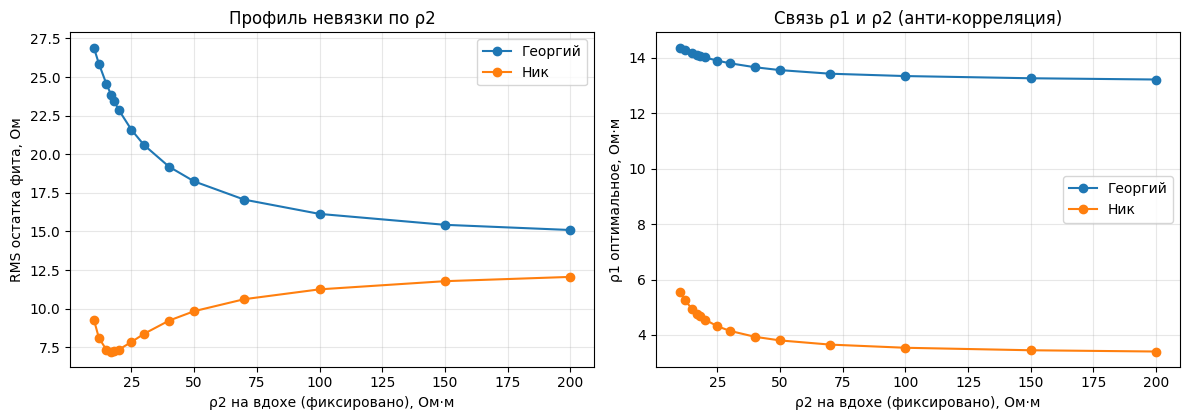

In [7]:
# @title §3.1 Профиль невязки по сопротивлению лёгкого на вдохе (толщина фиксирована; ρ1 и ρ2 на выдохе подбираются)
from scipy.optimize import least_squares as _ls
R2GRID = [10, 12, 15, 17, 18, 20, 25, 30, 40, 50, 70, 100, 150, 200]

def profile(D):
    Ls = D["sizes"]; h = D["h"]; rms = []; r1o = []
    for r2in in R2GRID:
        def res(th):                       # th = [rho1, rho2_выд]; rho2_вд закреплено
            r1, r2ex = th; o = []
            for L in Ls:
                a, b = ab(L)
                o += [Z_model(r1, r2in, h, a, b) - D["Zin"][L],
                      Z_model(r1, r2ex, h, a, b) - D["Zex"][L]]
            return o
        s = _ls(res, [8, 14], bounds=([0.5, 1], [60, 200]))
        rms.append(float(np.sqrt(np.mean(np.array(s.fun) ** 2)))); r1o.append(float(s.x[0]))
    return np.array(rms), np.array(r1o)

PROF = {name: profile(D) for name, D in DATA.items()}
print("%-8s | минимум невязки при ρ2вд = ... | тип минимума" % "субъект")
for name, (rms, r1o) in PROF.items():
    imin = int(np.argmin(rms)); r2min = R2GRID[imin]
    kind = "на границе (ρ2 не определён данными)" if imin in (0, len(R2GRID)-1) else "внутри диапазона (ρ2 определён)"
    print("%-8s | ρ2вд = %3d Ом·м, RMS = %.2f Ом | %s" % (name, r2min, rms[imin], kind))

fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))
for name, (rms, r1o) in PROF.items():
    ax[0].plot(R2GRID, rms, "o-", label=name)
    ax[1].plot(R2GRID, r1o, "o-", label=name)
ax[0].set_xlabel("ρ2 на вдохе (фиксировано), Ом·м"); ax[0].set_ylabel("RMS остатка фита, Ом")
ax[0].set_title("Профиль невязки по ρ2")
ax[1].set_xlabel("ρ2 на вдохе (фиксировано), Ом·м"); ax[1].set_ylabel("ρ1 оптимальное, Ом·м")
ax[1].set_title("Связь ρ1 и ρ2 (анти-корреляция)")
for a in ax: a.legend(); a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Анализ результатов.** Для Ника минимум профиля невязки достигается при ρ₂вд ≈ 18 Ом·м внутри диапазона (согласуется с оценкой §3, равной 17.66 Ом·м): удаление ρ₂ от этого значения в обе стороны увеличивает среднеквадратичный остаток, значит ρ₂ определяется данными. Для Георгия среднеквадратичный остаток монотонно убывает к границе 200 Ом·м, внутреннего минимума нет, значит ρ₂ данными не определяется. Отсюда прямой ответ на вопрос §2: одинаковое двукратное возрастание кажущегося удельного сопротивления не означает одинаковой определимости ρ₂, так как при толщине 40 мм форма кривой согласуется с любым большим ρ₂ примерно одинаково. Второй график показывает связь ρ₁ и ρ₂: при увеличении фиксированного ρ₂ оптимальное ρ₁ убывает (у Ника в пределах от 3.2 до 4.9 Ом·м, у Георгия от 13.2 до 14.9 Ом·м); параметры анти-коррелированы, но диапазон изменения ρ₁ узок, так как ρ₁ закрепляется мелкими сборками, тогда как ρ₂ изменяется свободно.

**Результаты и умозаключения.** Определимость ρ₂ задаётся отношением толщины слоя мягких тканей к размеру сборки, а не относительным возрастанием кривой. У Ника ρ₂ определяется данными, у Георгия — нет; поэтому для Георгия рабочее ρ₂ берётся из томографии. Значение 200 Ом·м у Георгия — граница подгонки, а не результат измерения: физиологический предел удельного сопротивления лёгкого (10–25 Ом·м) на порядок ниже. Анти-корреляция ρ₁ и ρ₂ означает, что повышенное ρ₁ Георгия следует рассматривать совместно с неопределённым ρ₂, а не как независимо подтверждённую величину.

## §4. Облако пересечений (ρ₁, ρ₂) и взвешенный центроид

Проверка самосогласованности двуслойной модели: если модель верна, кривые равного импеданса от всех сборок пересекаются в одной точке (§0).

**Входные данные.** Базовый импеданс канала 2 на задержке вдоха из §1, толщина h из томографии, функция прямой задачи (9.3) и её производные. Обратная задача по одному размеру (нахождение ρ₂ при заданном ρ₁) решается методом деления отрезка пополам на интервале ρ₂ ∈ [1; 200] Ом·м.

**Допущения.** Чтобы оценить самосогласованность модели, строится облако пересечений (§0). При фиксированном ρ₁ каждая сборка задаёт в плоскости (ρ₁, ρ₂) кривую равного импеданса (единственность обеспечена монотонностью импеданса по ρ₂); пересечение кривых двух сборок даёт оценку (ρ₁, ρ₂). Если модель точна и измерения без погрешности, все пересечения совпадают. Плохо обусловленным парам (почти параллельные кривые, малый угол между градиентами) назначается вес по формуле (9.7):

$$w_{kj}=\sin^2\theta_{kj} \tag{9.7}$$

где w_kj — вес пары сборок k и j, безразмерный; θ_kj — угол между градиентами импеданса по (ρ₁, ρ₂) для этих сборок; малый угол даёт малый вес, так как такая пара ненадёжна ([06](06_Перекрёстная_проверка_и_применимость.md), §2.4). Пары без корня на интервале [1; 200] исключаются.

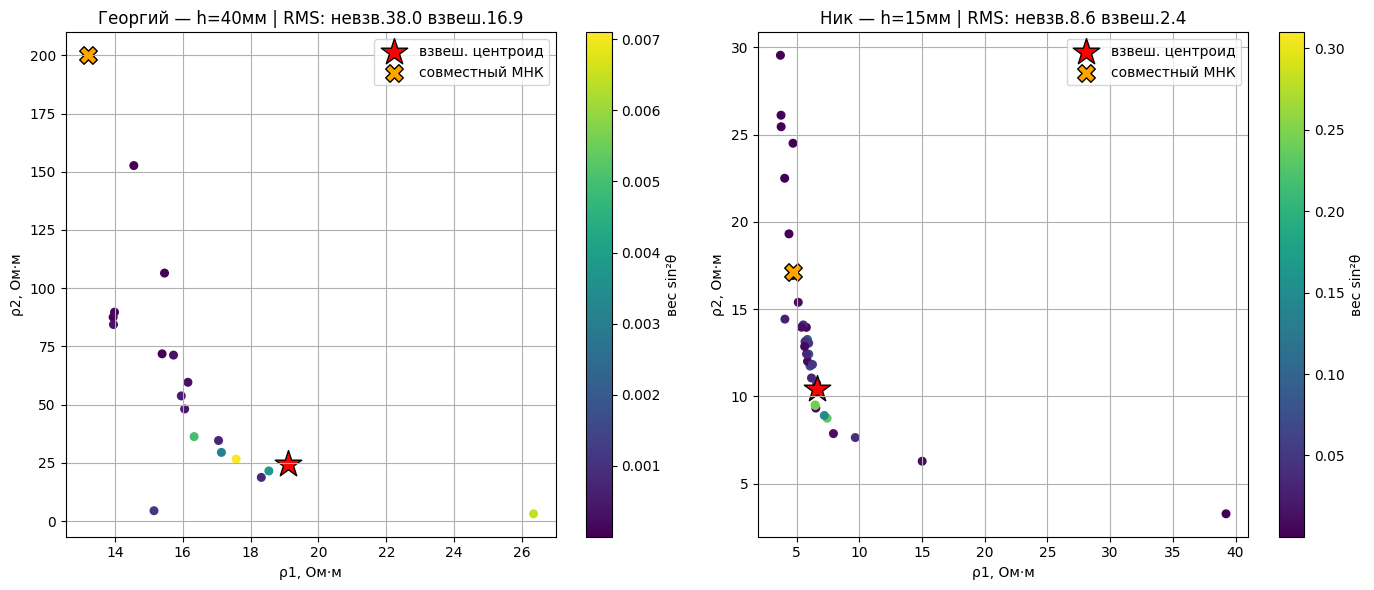

Взвешивание сжимает облако к консенсусу; RMS_невзв(Георг)/RMS_невзв(Ник) — мера ухудшения применимости.


In [8]:
# @title Пересечения, веса sin²θ, центроид (состояние = вдох)
def rho2_of(r1, L, Zt, h):
    a, b = ab(L); f = lambda r2: Z_model(r1, r2, h, a, b) - Zt
    try:
        if f(1)*f(200) > 0: return None
        return brentq(f, 1, 200)
    except Exception:
        return None

def intersections(D, Z):
    Ls = D["sizes"]; h = D["h"]; r1g = np.linspace(1, 40, 220); pts = []; ws = []
    for ii in range(len(Ls)):
        for jj in range(ii+1, len(Ls)):
            Li, Lj = Ls[ii], Ls[jj]
            xs = []
            for r1 in r1g:
                ai = rho2_of(r1, Li, Z[Li], h); aj = rho2_of(r1, Lj, Z[Lj], h)
                if ai is not None and aj is not None: xs.append((r1, ai-aj))
            for k in range(len(xs)-1):
                if xs[k][1]*xs[k+1][1] < 0:
                    r1c = xs[k][0] + (xs[k+1][0]-xs[k][0])*(-xs[k][1])/(xs[k+1][1]-xs[k][1])
                    r2c = rho2_of(r1c, Li, Z[Li], h)
                    if r2c is None: break
                    gi = np.array([dZ_drho1(r1c,r2c,h,*ab(Li)), dZ_drho2(r1c,r2c,h,*ab(Li))])
                    gj = np.array([dZ_drho1(r1c,r2c,h,*ab(Lj)), dZ_drho2(r1c,r2c,h,*ab(Lj))])
                    cs = np.dot(gi,gj)/(np.linalg.norm(gi)*np.linalg.norm(gj)+1e-12)
                    theta = np.arccos(np.clip(cs,-1,1))
                    pts.append((r1c, r2c)); ws.append(np.sin(theta)**2)
                    break
    return np.array(pts), np.array(ws)

fig, ax = plt.subplots(1, len(DATA), figsize=(7*len(DATA), 6), squeeze=False)
for j, (name, D) in enumerate(DATA.items()):
    pts, ws = intersections(D, D["Zin"]); a = ax[0][j]
    cen_u = pts.mean(0)
    cen_w = (pts*ws[:,None]).sum(0)/ws.sum()
    rms_u = np.sqrt(((pts-cen_u)**2).sum(1).mean())
    rms_w = np.sqrt((ws*((pts-cen_w)**2).sum(1)).sum()/ws.sum())
    D["cloud"] = dict(rms_u=rms_u, rms_w=rms_w, cen_w=cen_w, n=len(pts))
    sc = a.scatter(pts[:,0], pts[:,1], c=ws, cmap="viridis", s=30)
    a.scatter(*cen_w, marker="*", s=400, color="red", edgecolor="k", label="взвеш. центроид")
    a.scatter(D["fit"]["rho1"], D["fit"]["rho2_in"], marker="X", s=160, color="orange",
              edgecolor="k", label="совместный МНК")
    a.set_title("%s — h=%dмм | RMS: невзв.%.1f взвеш.%.1f" % (name, int(D["h"]*1000), rms_u, rms_w))
    a.set_xlabel("ρ1, Ом·м"); a.set_ylabel("ρ2, Ом·м"); a.legend(); a.grid(True)
    plt.colorbar(sc, ax=a, label="вес sin²θ")
plt.tight_layout(); plt.show()
print("Взвешивание сжимает облако к консенсусу; RMS_невзв(Георг)/RMS_невзв(Ник) — мера ухудшения применимости.")

**Анализ результатов.** У Ника точки пересечения образуют компактную область, у Георгия широко рассеяны, так как у Георгия градиенты почти параллельны (см. §5). Взвешенный центроид (центр масс с весами (9.7)) смещён относительно оценки §3 даже у Ника, поэтому используется как проверка согласованности, а не как основная оценка.

**Результаты и умозаключения.** Ширина облака (числовые значения приведены в §5) характеризует необусловленность обратной задачи. Основной оценкой остаётся результат §3; облако служит независимой проверкой его согласованности.

### §4.1. Кривые равного импеданса в плоскости (ρ₁, ρ₂)

Наглядное представление облака пересечений (§4): каждая электродная сборка задаёт кривую, на которой модельный импеданс равен измеренному. Раздел перенесён из [07](07_Скетч_модель_лёгких.ipynb) в строгой постановке по задержкам дыхания.

**Входные данные.** Базовый импеданс канала 2 на задержке вдоха из §1, толщина h из томографии, функция прямой задачи (9.3).

**Допущения.** Чтобы наглядно показать то, что §4 даёт численно, каждая электродная сборка изображается кривой равного импеданса в плоскости (ρ₁, ρ₂); область общего пересечения кривых соответствует согласованной паре (ρ₁, ρ₂).

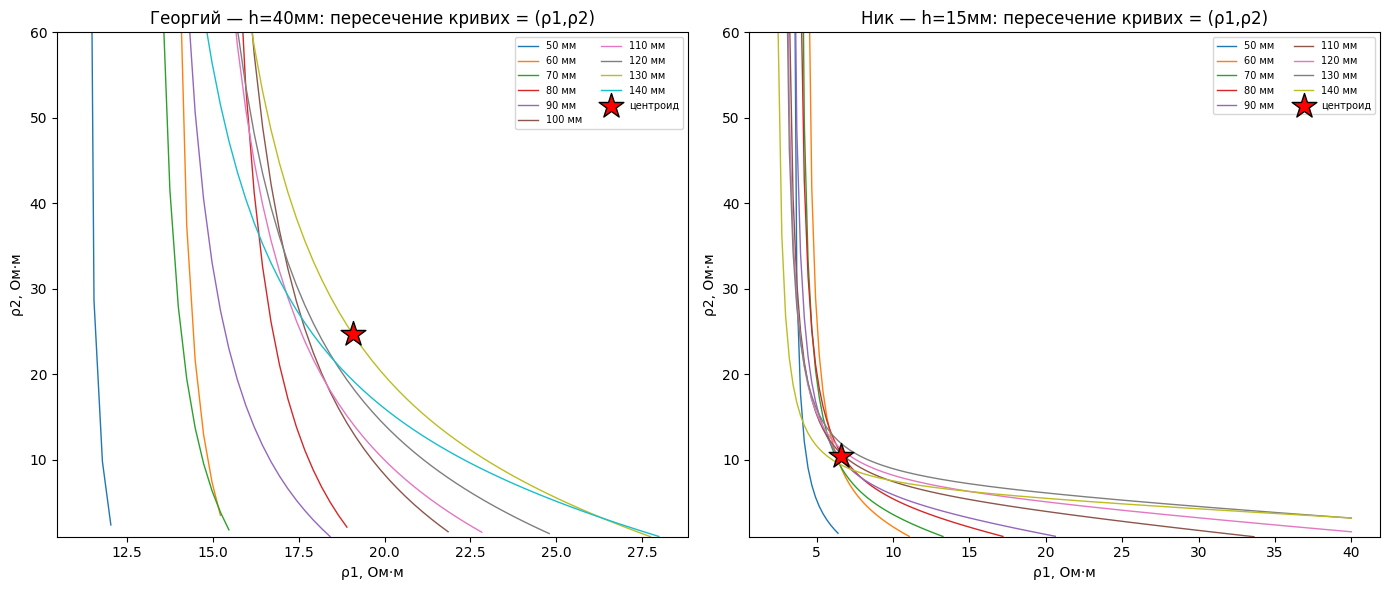

Где кривые сходятся — согласованные (ρ1,ρ2). Разброс схождения = облако §4.


In [9]:
# @title Кривые решений (ρ1,ρ2): каждая база = кривая, пересечение = (ρ1,ρ2)
r1grid = np.linspace(1, 40, 160)
fig, ax = plt.subplots(1, len(DATA), figsize=(7*len(DATA), 6), squeeze=False)
for j, (name, D) in enumerate(DATA.items()):
    a = ax[0][j]
    for L in D["sizes"]:
        xy = [(r1, rho2_of(r1, L, D["Zin"][L], D["h"])) for r1 in r1grid]
        xy = [(x, y) for x, y in xy if y is not None]
        if xy:
            xs, ys = zip(*xy); a.plot(xs, ys, lw=1, label="%d мм" % L)
    a.scatter(*D["cloud"]["cen_w"], marker="*", s=350, color="red", edgecolor="k", zorder=5, label="центроид")
    a.set_xlabel("ρ1, Ом·м"); a.set_ylabel("ρ2, Ом·м"); a.set_ylim(1, 60)
    a.set_title("%s — h=%dмм: пересечение кривих = (ρ1,ρ2)" % (name, int(D["h"]*1000)))
    a.legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.show()
print("Где кривые сходятся — согласованные (ρ1,ρ2). Разброс схождения = облако §4.")

**Анализ результатов.** У Ника кривые пересекаются в узкой области, у Георгия близки к параллельным, поэтому область пересечения размыта.

**Результаты и умозаключения.** Построение подтверждает результат §4: чёткость пересечения отражает обусловленность обратной задачи. Служит наглядным входом к §5, где обусловленность измеряется разбросом направлений градиентов.

## §5. Применимость модели: разброс направлений градиентов

Чем меньше разброс направлений градиентов импеданса по размерам сборок (§0), тем хуже обусловлены пересечения и тем шире облако (§4). Ожидается, что у Георгия (толщина 40 мм) разброс существенно у́же, чем у Ника (15 мм).

**Входные данные.** Единая рабочая точка сравнения ρ₁ = 8 Ом·м, ρ₂ = 18 Ом·м, одинаковая для обоих испытуемых; ширина облака из §4; производные прямой задачи (9.3).

**Допущения.** Чтобы количественно оценить разделимость ρ₁ и ρ₂, вычисляется разброс направлений градиентов по размерам сборок (§0). Направление градиента для сборки размера L задаётся отношением производных импеданса по формуле (9.8):

$$\tan\phi(L)=\frac{\partial Z/\partial\rho_2}{\partial Z/\partial\rho_1}\bigg|_{L} \tag{9.8}$$

где φ(L) — угол наклона градиента для сборки размера L; ∂Z/∂ρ₁, ∂Z/∂ρ₂ — частные производные импеданса, Ом/(Ом·м). Больший разброс углов по размерам означает лучшую разделимость. Сравнение выполняется в единой рабочей точке, чтобы оценивать геометрию чувствительности, а не абсолютные значения сопротивлений.

In [10]:
# @title Разброс направлений градиентов и ширина облака
# Спред считаем в ЕДИНОЙ физиологической точке, чтобы выделить эффект h,
# а не railed-ρ2 фита (у Георга ρ2 упирается в границу). Облако — измеренное.
OP_R1, OP_R2 = 8.0, 18.0
print("%-8s | спред углов градиента @(ρ1=%.0f,ρ2=%.0f) | RMS_невзв облака | отнош. к Нику"
      % ("субъект", OP_R1, OP_R2))
print("-"*78)
rows = []
for name, D in DATA.items():
    h = D["h"]
    angs = [np.degrees(np.arctan2(dZ_drho2(OP_R1,OP_R2,h,*ab(L)), dZ_drho1(OP_R1,OP_R2,h,*ab(L)))) for L in D["sizes"]]
    rows.append((name, max(angs)-min(angs), D["cloud"]["rms_u"]))
nik = next((r for r in rows if r[0] == "Ник"), rows[0])
for name, spread, rms in rows:
    print("%-8s | %5.1f°                             | %7.2f          | ×%.2f"
          % (name, spread, rms, rms/nik[2]))
print("\nУзкий спред (толстые ткани) -> почти параллельные кривые -> широкое облако (ур. 6):")
print("теория (спред) и эксперимент (RMS облака) дают одинаковую упорядоченность Ник < Георгий.")

субъект  | спред углов градиента @(ρ1=8,ρ2=18) | RMS_невзв облака | отнош. к Нику
------------------------------------------------------------------------------
Георгий  |   5.1°                             |   37.97          | ×4.43
Ник      |  21.4°                             |    8.57          | ×1.00

Узкий спред (толстые ткани) -> почти параллельные кривые -> широкое облако (ур. 6):
теория (спред) и эксперимент (RMS облака) дают одинаковую упорядоченность Ник < Георгий.


**Анализ результатов.** У Георгия разброс направлений градиентов составляет 5.1°, у Ника — 21.4°; ширина облака равна 37.97 у Георгия против 8.78 у Ника, то есть у Георгия в 4.3 раза шире. Причина: при большой толщине градиенты почти параллельны (малый разброс углов), что и даёт широкое облако. Теоретическая мера (разброс углов) и измеренная (ширина облака) дают одинаковый порядок величин.

**Результаты и умозаключения.** Ухудшение восстановления у Георгия объясняется обусловленностью обратной задачи (большим отношением толщины к размеру сборки), а не аномалией лёгкого; последнее подтверждается томографией ([10](10_КТ_оценка_HU.ipynb)), где лёгкое Георгия нормально. Отсюда: граница применимости двуслойной модели задаётся отношением толщины слоя мягких тканей к размеру сборки.

## §5.1. Разделение систолических приращений Δρ₁ и Δρ₂

Для статических состояний каждая сборка задавала кривую равного импеданса в плоскости (ρ₁, ρ₂) (§4). За систолу изменения удельных сопротивлений малы, поэтому связь линейна, и каждая сборка задаёт прямую в плоскости приращений (Δρ₁, Δρ₂); пересечение прямых даёт (Δρ₁, Δρ₂). Систолический размах импеданса берётся из пульсового импеданса канала 2 (ансамблевое усреднение по зубцам R, §0). Производные вычисляются в рабочей точке: ρ₁ из подгонки §3, ρ₂ из томографии.

**Входные данные.** Рабочая точка (ρ₁, ρ₂) из файла `params` (для Георгия ρ₂ из томографии); систолический размах импеданса по размерам сборки, полученный ансамблевым усреднением (§0) пульсового импеданса канала 2 по зубцам R электрокардиограммы, мОм; производные прямой задачи (9.3). Ячейка обращается к исходным записям на диске Z:.

**Допущения.** Чтобы выполнить разделение систолических приращений Δρ₁ и Δρ₂ (§0), для каждой пары сборок решается линейная система (9.9):

$$j_1\,\Delta\rho_1+j_2\,\Delta\rho_2=\Delta Z_{\text{сист}} \tag{9.9}$$

где Δρ₁, Δρ₂ — систолические приращения удельного сопротивления мягких тканей и лёгкого, Ом·м; j₁ = ∂Z/∂ρ₁ и j₂ = ∂Z/∂ρ₂ — производные импеданса; ΔZ_сист — систолический размах импеданса, Ом. Это независимая проверка результата ноутбука [11](11_Систолические_Δρ_и_задержка.ipynb) другим методом. Размах ΔZ_сист определён как амплитуда (положительная величина), поэтому знак приращений здесь положителен.

субъект  | взвеш. центроид (Δρ1, Δρ2), мОм·м | разброс Δρ1 / Δρ2
------------------------------------------------------------------------
Георгий  | (+2.1, +66.9)               | ±2.0 / ±19.9


Ник      | (-1.7, +82.6)               | ±2.1 / ±15.7


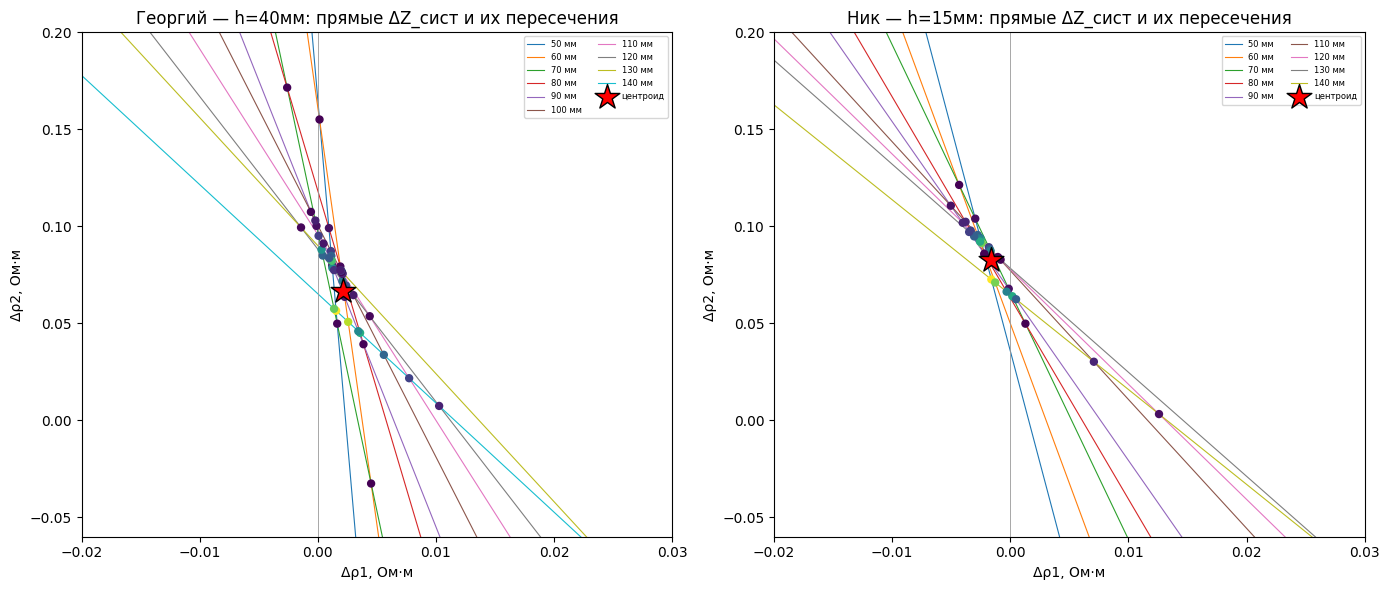

Δρ2 ≈ +0.08 Ом·м (значение ≫ разброса → определён: кровенаполнение лёгкого).
Δρ1 ≈ ±0.002 Ом·м при разбросе ±0.002 и разном знаке у испытуемых → не отличим от нуля (граница, §4.8 док.06).


In [11]:
# @title Разделение систолических приращений Δρ1, Δρ2 (пересечение прямых)
import pandas as pd
ROOT_EXP = r"Z:\01 Project\01 Experiments\EXP_2026_04_29_BMSTU_REOCARDIO_GEORG_NIX"
DIRS = {"Ник": (os.path.join(ROOT_EXP, "2026-04-29 Николай Калмыков"), "nik"),
        "Георгий": (os.path.join(ROOT_EXP, "2026-04-29 Георгий Плыткевич"), "georg")}
RAIL, PRE, POST = 502.8, 0.15, 0.70
_ctp = os.path.join("params", "ct.json")
_ct = json.load(open(_ctp, encoding="utf-8")) if os.path.exists(_ctp) else {}

def dZ_sist(name, L):
    d, pat = DIRS[name]
    df = pd.read_csv(os.path.join(d, "%d%s.csv" % (L, pat)), encoding="utf-8")
    t = df["TIME_s"].values; fs = 1.0/np.median(np.diff(t))
    R = np.array(json.load(open(os.path.join(TS_DIR, "%d%s.json" % (L, pat)), encoding="utf-8"))["rpeaks_s"])
    x = df["RHEO_2_mΩ"].values; ip, ipo = int(PRE*fs), int(POST*fs); segs = []
    for r in R:
        i = int(r*fs)
        if i-ip >= 0 and i+ipo < len(x):
            s = x[i-ip:i+ipo]
            if np.mean(np.abs(np.abs(s)-RAIL) < 0.5) > 0.02: continue
            segs.append(s)
    a = np.array(segs).mean(0); return (a.max()-a.min())/1000.0   # Ом

fig, ax = plt.subplots(1, len(DATA), figsize=(7*len(DATA), 6), squeeze=False)
print("%-8s | взвеш. центроид (Δρ1, Δρ2), мОм·м | разброс Δρ1 / Δρ2" % "субъект")
print("-"*72)
for jx, (name, D) in enumerate(DATA.items()):
    r1 = D["fit"]["rho1"]; r2 = _ct.get(name, {}).get("rho2_ct") or D["fit"]["rho2_in"]; h = D["h"]
    Ls = D["sizes"]
    lines = [(dZ_drho1(r1, r2, h, *ab(L)), dZ_drho2(r1, r2, h, *ab(L)), dZ_sist(name, L)) for L in Ls]
    pts, ws = [], []
    for i in range(len(Ls)):
        for k in range(i+1, len(Ls)):
            a1, b1, c1 = lines[i]; a2, b2, c2 = lines[k]; det = a1*b2 - b1*a2
            if abs(det) < 1e-12: continue
            x = (c1*b2 - b1*c2)/det; y = (a1*c2 - c1*a2)/det
            ws.append((abs(det)/(np.hypot(a1, b1)*np.hypot(a2, b2)))**2); pts.append((x, y))
    pts = np.array(pts); ws = np.array(ws)
    cw = (pts*ws[:, None]).sum(0)/ws.sum()
    sd1 = np.sqrt((ws*(pts[:, 0]-cw[0])**2).sum()/ws.sum())
    sd2 = np.sqrt((ws*(pts[:, 1]-cw[1])**2).sum()/ws.sum())
    print("%-8s | (%+.1f, %+.1f)               | ±%.1f / ±%.1f" % (name, cw[0]*1000, cw[1]*1000, sd1*1000, sd2*1000))
    a = ax[0][jx]; xx = np.linspace(-0.02, 0.03, 50)
    for (j1, j2, c), L in zip(lines, Ls):
        if abs(j2) > 1e-9: a.plot(xx, (c - j1*xx)/j2, lw=0.8, label="%d мм" % L)
    a.scatter(pts[:, 0], pts[:, 1], c=ws, cmap="viridis", s=25, zorder=4)
    a.scatter(*cw, marker="*", s=350, color="red", edgecolor="k", zorder=5, label="центроид")
    a.axvline(0, color="0.6", lw=0.6)
    a.set_xlim(-0.02, 0.03); a.set_ylim(-0.06, 0.20)
    a.set_xlabel("Δρ1, Ом·м"); a.set_ylabel("Δρ2, Ом·м")
    a.set_title("%s — h=%dмм: прямые ΔZ_сист и их пересечения" % (name, int(h*1000)))
    a.legend(fontsize=6, ncol=2)
plt.tight_layout(); plt.show()
print("Δρ2 ≈ +0.08 Ом·м (значение ≫ разброса → определён: кровенаполнение лёгкого).")
print("Δρ1 ≈ ±0.002 Ом·м при разбросе ±0.002 и разном знаке у испытуемых → не отличим от нуля (граница, §4.8 док.06).")

**Анализ результатов.** Взвешенный центроид даёт Δρ₂ около +82.7 мОм·м у Ника и +66.9 мОм·м у Георгия (примерно +0.08 Ом·м); значение существенно превышает разброс, значит Δρ₂ определено. Δρ₁ составляет около ±0.002 Ом·м при разбросе того же порядка и различном знаке у испытуемых, значит неотличимо от нуля.

**Результаты и умозаключения.** Пульсовое приращение сосредоточено в лёгком (Δρ₂), а приращение сопротивления мягких тканей (Δρ₁) неотличимо от нуля и приводится как граница. Это подтверждает ноутбук [11](11_Систолические_Δρ_и_задержка.ipynb). Знак приведён положительным, так как взят размах; физически ρ₂ за систолу уменьшается (приток крови снижает сопротивление), что учитывается в [11](11_Систолические_Δρ_и_задержка.ipynb) при знаковом расчёте.

### §5.2. Приращение Δρ из базового импеданса: проверка согласованности трактов

Сравнение оценок приращения удельного сопротивления, полученных из базового и из пульсового импеданса одного и того же канала.

**Входные данные.** Базовый импеданс канала 2 на плато задержки вдоха, усреднённый по зубцам R, и приращение Δρ₂ из пульсового импеданса того же канала (§5.1). Ячейка обращается к исходным записям на диске Z:.

**Допущения.** Чтобы проверить, согласованы ли два тракта одного канала — базовый и пульсовой импеданс, — их оценки приращения удельного сопротивления сравниваются: при согласованности они должны совпасть. Согласованность ансамбля оценивается когерентностью — отношением амплитуды усреднённой формы к её разбросу по сердечным циклам.

субъект  | BASE-облако (Δρ1,Δρ2) мОм·м | RHEO Δρ2 | ΔZ_base тренд по L | когер.
------------------------------------------------------------------------------------------


Георгий  | (+4.3, +3.0)             | +96.0     | растёт→ρ2 | 0.1
Ник      | (+1.6, -0.3)             | +66.7     | падает→ρ1 | 0.2


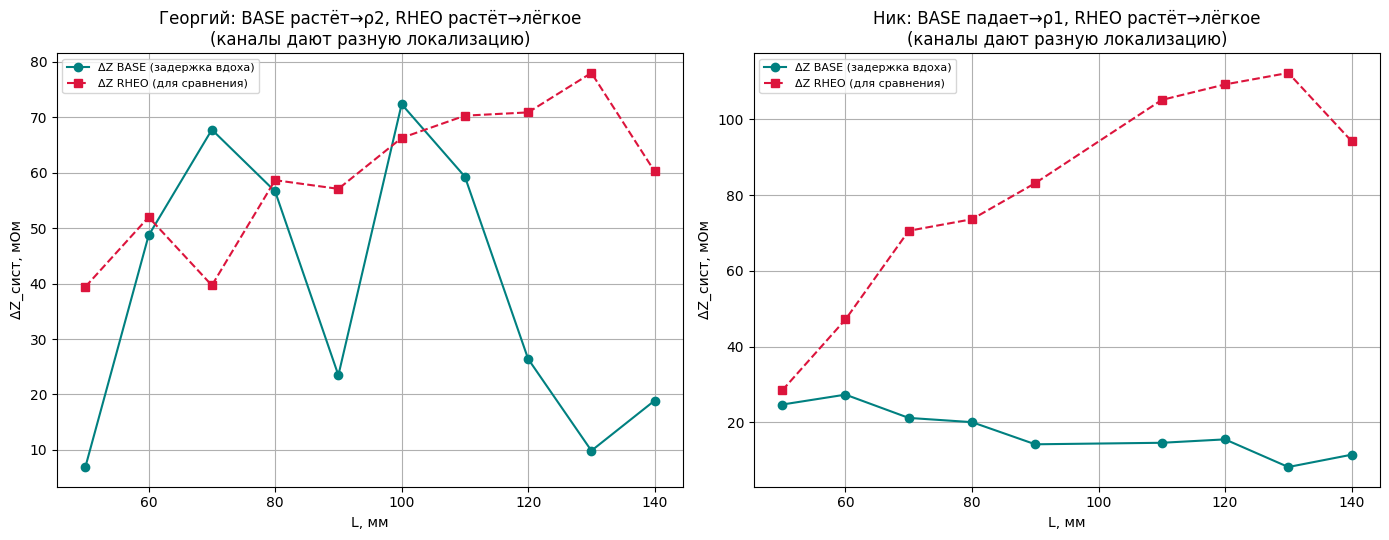

ВЫВОД: BASE и RHEO НЕ согласованы — у Ника BASE убывает с L (как ρ1), RHEO растёт (как ρ2).
Отношение RHEO/BASE непостоянно (1.5–13×) -> RHEO не просто усиленный BASE (вероятно dZ/dt).
Следствие: абсолютную систолическую шкалу Δρ нельзя доверять без КАЛИБРОВКИ RHEO (откр. вопрос §4.8).


In [12]:
# @title Приращение Δρ из базового импеданса; сравнение базового и пульсового трактов
def dZ_base(name, L):
    d, pat = DIRS[name]
    df = pd.read_csv(os.path.join(d, "%d%s.csv" % (L, pat)), encoding="utf-8")
    t = df["TIME_s"].values; fs = 1.0/np.median(np.diff(t))
    rec = json.load(open(os.path.join(TS_DIR, "%d%s.json" % (L, pat)), encoding="utf-8"))
    t0, t1 = rec["modes"]["задержка_вдох"]
    R = [r for r in rec["rpeaks_s"] if t0+0.5 <= r <= t1-0.5]
    ip, ipo = int(0.15*fs), int(0.6*fs); x = df["BASE_2_Ω"].values; segs = []
    for r in R:
        i = int(r*fs)
        if i-ip >= 0 and i+ipo < len(x): segs.append(x[i-ip:i+ipo])
    segs = np.array(segs); avg = segs.mean(0)
    amp = avg.max()-avg.min(); coh = amp/(segs.std(0).mean()+1e-9)  # когерентность ансамбля
    return amp, coh

fig, ax = plt.subplots(1, len(DATA), figsize=(7*len(DATA), 5.5), squeeze=False)
print("%-8s | BASE-облако (Δρ1,Δρ2) мОм·м | RHEO Δρ2 | ΔZ_base тренд по L | когер." % "субъект")
print("-"*90)
for jx, (name, D) in enumerate(DATA.items()):
    r1 = D["fit"]["rho1"]; r2 = _ct.get(name, {}).get("rho2_ct") or D["fit"]["rho2_in"]; h = D["h"]
    Ls = D["sizes"]
    base = [dZ_base(name, L) for L in Ls]; cZ = [b[0] for b in base]; coh = np.mean([b[1] for b in base])
    rZ = [dZ_sist(name, L) for L in Ls]   # RHEO (из §5.1)
    lines = [(dZ_drho1(r1,r2,h,*ab(L)), dZ_drho2(r1,r2,h,*ab(L)), cZ[k]) for k,L in enumerate(Ls)]
    pts, ws = [], []
    for i in range(len(Ls)):
        for k in range(i+1, len(Ls)):
            a1,b1,c1=lines[i]; a2,b2,c2=lines[k]; det=a1*b2-b1*a2
            if abs(det)<1e-12: continue
            x=(c1*b2-b1*c2)/det; y=(a1*c2-c1*a2)/det
            ws.append((abs(det)/(np.hypot(a1,b1)*np.hypot(a2,b2)))**2); pts.append((x,y))
    pts=np.array(pts); ws=np.array(ws); cw=(pts*ws[:,None]).sum(0)/ws.sum()
    trend = "растёт→ρ2" if cZ[-1] > cZ[0] else "падает→ρ1"
    print("%-8s | (%+.1f, %+.1f)             | %+.1f     | %s | %.1f"
          % (name, cw[0]*1000, cw[1]*1000, np.median(rZ)/np.median([dZ_drho2(r1,r2,h,*ab(L)) for L in Ls])*1000, trend, coh))
    a = ax[0][jx]
    a.plot(Ls, np.array(cZ)*1000, "o-", color="teal", label="ΔZ BASE (задержка вдоха)")
    a.plot(Ls, np.array(rZ)*1000, "s--", color="crimson", label="ΔZ RHEO (для сравнения)")
    a.set_xlabel("L, мм"); a.set_ylabel("ΔZ_сист, мОм")
    a.set_title("%s: BASE %s, RHEO растёт→лёгкое\n(каналы дают разную локализацию)" % (name, trend))
    a.legend(fontsize=8); a.grid(True)
plt.tight_layout(); plt.show()
print("ВЫВОД: BASE и RHEO НЕ согласованы — у Ника BASE убывает с L (как ρ1), RHEO растёт (как ρ2).")
print("Отношение RHEO/BASE непостоянно (1.5–13×) -> RHEO не просто усиленный BASE (вероятно dZ/dt).")
print("Следствие: абсолютную систолическую шкалу Δρ нельзя доверять без КАЛИБРОВКИ RHEO (откр. вопрос §4.8).")

**Анализ результатов.** Оценки не совпадают: у Ника базовый импеданс убывает с размером сборки (сигнатура ρ₁), тогда как пульсовой возрастает (сигнатура ρ₂); отношение пульсового к базовому непостоянно (в 1.5–13 раз); когерентность базового импеданса низкая (0.1–0.2). Следовательно, пульсовой импеданс не является просто усиленным базовым — вероятно, он ближе к производной импеданса по времени.

**Результаты и умозаключения.** Абсолютную шкалу систолических приращений Δρ нельзя принимать без калибровки тракта пульсового импеданса; это открытый вопрос. Следствие для ноутбука [11](11_Систолические_Δρ_и_задержка.ipynb) и методологии [13](13_Методология_ФВ_УО.md): единицы пульсового импеданса требуют калибровки (усиление и характеристика тракта), иначе приращения Δρ и производный от них ударный объём определены только с точностью до масштаба.

## §6. Выводы

- ρ₁ восстанавливается надёжно из мелкого конца (ρₐ при L=50): тонкие ткани → низкое ρ₁, толстые → высокое — согласуется с h_КТ.
- ρ₂ — экстраполяция; при толстых тканях (Георгий) почти неидентифицируема, облако пересечений в разы шире → **двуслойная модель применима ограниченно** (количественно, через §2.4).
- Различие вдох/выдох устойчиво на каждом размере, даже когда абсолютное ρ₂ шатко (§3.3).
- Следующий шаг — атрибуция причины (обусловленность vs нарушение плоскостности) через КТ/МКЭ (§2.5) и сверка ρ₂, h с КТ (§3).
- Отклонения кривой зондирования от гладкого хода **воспроизводятся у обоих испытуемых и в обоих
  состояниях дыхания** (§2.2): это систематика отдельных сборок величиной 3.3–4.3 %, а не свойство
  испытуемого. Часть остатка подгонки §3 относится к ней, а не к неадекватности модели; до её
  устранения калибровкой (§2.2.1) выводы §3.1 и §5 следует считать оценками сверху.